### **Load Dependencies**

In [1]:
import time
from prompts import *
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from IPython.display import Markdown, display, Image

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

- **Load Docs**

In [2]:
docs = (
    PyPDFLoader("./docs/Company_Policies.pdf").load()
    + PyPDFLoader("./docs/Company_Profile.pdf").load()
    + PyPDFLoader("./docs/Product_and_Pricing.pdf").load()
)

- **Split Docs into Chunks**

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

- **Embed Chunks and Create Retriever**

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

- **Create LLM**

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### **Graph Building**

- **Graph State**

In [6]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    retrieval_query: str
    rewrite_tries: int

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    # post answer generation reflection
    is_sup: Literal["fully_supported", "partially_supported", "not_supported"]
    evidence: str

    retries: int

    is_useful: Literal["useful", "not_useful"]
    use_reason: str

#### **Decide Retrieval Node**
- Decide whether retrieval is necessary for answering the question

In [7]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="Whether the agent should perform retrieval to answer the question."
    )

In [8]:
def decide_retrieval(state: State) -> dict:
    """ This function uses the LLM to decide whether retrieval is necessary to answer the question."""

    should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_prompt(question=state["question"])
    )
    
    return { "need_retrieval" : decision.should_retrieve }

In [9]:
decision = decide_retrieval({"question": "What is refund policy of NexaAI?"})
decision

{'need_retrieval': True}

#### **Generate Answer**
- Generate a direct answer to the question.

In [10]:
def generate_direct(state: State) -> dict:
    """ This function uses the LLM to generate a direct answer to the question."""

    answer = llm.invoke(
        direct_generation_prompt.format_prompt(question=state["question"])
    )
    return {"answer": answer.content}

In [11]:
answer = generate_direct({ "question" : "What is Machine Learning?" })['answer']
# display(Markdown(answer))

#### **Retrieve Docs**
- Retrieve docs using the retriever

In [12]:
def retrieve(state: State) -> dict:
    """ This function performs retrieval using the retriever and returns the retrieved documents."""
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}

In [13]:
retrieved_docs = retrieve({"question": "What is refund policy of NexaAI?"})

In [14]:
display(Markdown(retrieved_docs['docs'][0].page_content))

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms


#### **Decide Relevance**
- Decide whether a retrieved document is relevant to answer the question

In [15]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

def decide_relevance(state: State) -> dict:
    """ This function uses the LLM to decide whether a retrieved document is relevant to answer the question."""

    relevance_llm = llm.with_structured_output(RelevanceDecision)
    
    relevant_docs: List[Document] = []
    irrelevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)
        else:
            irrelevant_docs.append(doc)

    return {"relevant_docs": relevant_docs, "irrelevant_docs": irrelevant_docs}

In [16]:
relevant_docs = decide_relevance({
    "question": "What is refund policy of NexaAI?",
    "docs": retrieved_docs["docs"]
})

In [17]:
relevant_docs['relevant_docs']

[]

In [18]:
len(retrieved_docs['docs'])

4

In [19]:
len(relevant_docs['irrelevant_docs'])

4

#### **Generate Answer From Context**
- Generate an answer to the question using the retrieved context

In [20]:
def generate_from_context(state: State) -> dict:
    """ This function uses the LLM to generate an answer to the question using the retrieved context."""

    context = "\n\n---\n\n".join(
        [doc.page_content for doc in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return { "answer" : "No relevant document found.", "context": "" }

    output = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": output.content, "context": context}

In [21]:
answer = generate_from_context({
    "question": "What is refund policy of NexaAI?",
    "relevant_docs": relevant_docs["relevant_docs"]
})

In [22]:
display(Markdown(answer['answer']))

No relevant document found.

#### **No Relevant Docs**
- Generate an answer when no relevant documents are found

In [23]:
def no_relevant_docs(state: State) -> dict:
    """ This function generates an answer when no relevant documents are found."""

    return { "answer" : "No relevant document found.", "context": "" }

#### **Is Supported**
- Decide whether the generated answer is supported by the retrieved documents

In [24]:
class IsSupported(BaseModel):
    
    is_supported: Literal["fully_supported", "partially_supported", "not_supported"]
    evidence: List[str] = Field(default_factory=list)

In [25]:
def is_support(state: State) -> dict:
    """ This function uses the LLM to decide whether the generated answer is supported by the retrieved documents."""
    
    is_supported_llm = llm.with_structured_output(IsSupported)

    decision: IsSupported = is_supported_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state["answer"],
            context=state.get("context", "")
        )
    )

    return { "is_sup": decision.is_supported, "evidence": decision.evidence }

In [26]:
support = is_support({
    "question": "What is refund policy of NexaAI?",
    "answer": answer['answer'],
    "context": answer['context']
})

In [27]:
support

{'is_sup': 'not_supported', 'evidence': []}

#### **Accept Answer**
- Keep the generated answer as it is

In [28]:
def accept_answer(state: State) -> dict:

    # keep the answer as it is
    return {}

#### **Revise Answer**
- Revise the generated answer based on the evidence provided by the is_support function

In [29]:
def revise_answer(state: State) -> dict:
    """ This function uses the LLM to revise the answer based on the evidence provided by the is_support function."""

    revised_answer = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state["answer"],
            context=state.get("context", ""),
        )
    )

    return { "answer": revised_answer.content, "retries": state.get("retries", 0) + 1 }

In [30]:
class IsUseful(BaseModel):
    is_useful: Literal["useful", "not_useful"]
    reason: str = Field(
        ...,
        description="Short reason in 1 line."
    )

In [31]:
def is_useful(state: State) -> dict:
    """ This function uses the LLM to decide whether the generated answer is useful in addressing the user's question."""

    is_useful_llm = llm.with_structured_output(IsUseful)

    decision: IsUseful = is_useful_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state["answer"],
        )
    )

    return { "is_useful": decision.is_useful, "use_reason": decision.reason }

In [32]:
issue = is_useful({
    "question": "What is refund policy of NexaAI?",
    "answer": answer['answer']
})

In [33]:
issue

{'is_useful': 'not_useful',
 'use_reason': 'The answer does not provide any information about the refund policy.'}

#### **Rewrite Query**
- Rewrite the query based on the evidence provided by the is_support function

In [34]:
class RewrittenQuery(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

In [39]:
def rewrite_question(state: State) -> dict:
    """ This function uses the LLM to rewrite the question based on the evidence provided by the is_support function."""

    decision = llm.with_structured_output(RewrittenQuery).invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", "")
        )
    )

    return {"retrieval_query": decision.retrieval_query, "rewrite_tries": state.get("rewrite_tries", 0) + 1}

In [40]:
rewritten_query = rewrite_question({
    "question": "What is refund policy of NexaAI?",
    "answer": answer['answer']
})

In [42]:
rewritten_query

{'retrieval_query': 'NexaAI refund policy terms conditions process',
 'rewrite_tries': 1}

#### **Router**
- route_after_decide: This function routes the state to the appropriate function based on whether retrieval is needed or not.

In [43]:
def router_after_decide(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether retrieval is needed or not."""
    
    if state["need_retrieval"]:
        return "need_retrieval"
    else:
        return "generate_direct"

- route_after_relevance: This function routes the state to the appropriate function based on whether relevant documents are found or not.

In [44]:
def route_after_relevance(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether relevant documents are found or not."""
    
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "context"
    else:
        return "irrelevant"

- route_after_support: This function routes the state to the appropriate function based on whether the generated answer is supported or not.

In [45]:
MAX_RETRIES = 5

def route_after_support(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether the generated answer is supported or not."""

    # accept the answer if it is fully supported
    if state.get("is_sup") == "fully_supported":
        return "accept"
    
    # accept the answer if we have reached the maximum number of retries
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept"
    
    # otherwise, refine the answer
    return "refine"

- route_after_issue: This function routes the state to the appropriate function based on whether the generated answer is useful or not.

In [47]:
def route_after_issue(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether the generated answer is useful or not."""

    if state.get("is_useful") == "useful":
        return "end"
    
    if state.get("rewrite_tries", 0) >= MAX_RETRIES:
        return "no_answer_found"

    return "rewrite"

#### **Graph Building**

In [50]:
# State graph construction
builder = StateGraph(State)

# ============================= Nodes =============================
builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("retrieve", retrieve)
builder.add_node("generate_answer", generate_direct)

builder.add_node("decide_relevance", decide_relevance)
builder.add_node("generate_from_context", generate_from_context)
builder.add_node("no_relevant_docs", no_relevant_docs)

builder.add_node("is_supported", is_support)
builder.add_node("revise_answer", revise_answer)

builder.add_node("is_useful", is_useful)

builder.add_node("rewrite_question", rewrite_question)
# ================================================================

# 
builder.add_edge(START, "decide_retrieval")

builder.add_conditional_edges(
    "decide_retrieval", router_after_decide,
    {
        "need_retrieval": "retrieve",
        "generate_direct": "generate_answer"
    }
)
builder.add_edge("generate_answer", END)

builder.add_edge("retrieve", "decide_relevance")
builder.add_conditional_edges(
    "decide_relevance", route_after_relevance,
    {
        "context": "generate_from_context",
        "irrelevant": "no_relevant_docs"
    }
)
builder.add_edge("no_relevant_docs", END)

builder.add_edge("generate_from_context", "is_supported")
builder.add_conditional_edges(
    "is_supported", route_after_support,
    {
        "accept": "is_useful",
        "refine": "revise_answer"
    }
)
builder.add_edge("revise_answer", "is_supported")

builder.add_conditional_edges(
    "is_useful", route_after_issue,
    {
        "end": END,
        "no_answer_found": "no_relevant_docs",
        "rewrite": "rewrite_question"
    }
)
builder.add_edge("rewrite_question", "retrieve")


# ================================ Compile graph ================================
rag = builder.compile()

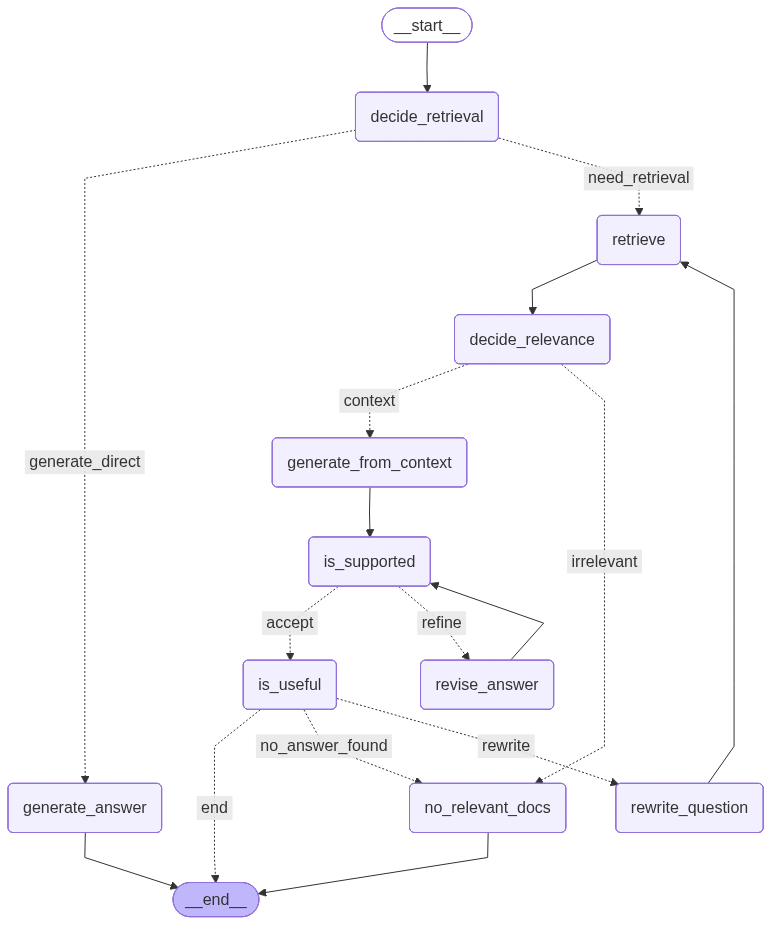

In [51]:
display(Image(rag.get_graph().draw_mermaid_png()))

#### **Test Graph**

In [53]:
result = rag.invoke(
    {
        "question": "Describe NexaAI’s company culture.",
        "retrieval_query": "What is the refund policy of NexaAI",
        "rewrite_tries": 0,
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "is_sup": "",
        "evidence": [],
        "retries": 0,
        "is_useful": "",
        "use_reason": ""
    },
    config={"recursion_limit": 80},
)

print(result["answer"])

- "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


In [54]:
result.keys()

dict_keys(['question', 'need_retrieval', 'retrieval_query', 'rewrite_tries', 'docs', 'relevant_docs', 'context', 'answer', 'is_sup', 'evidence', 'retries', 'is_useful', 'use_reason'])

In [55]:
result['need_retrieval']

True

In [56]:
for doc in result['docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Profile.pdf

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision

******************************************************************************************************************************************************

**Source:** ./docs/Company_Policies.pdf

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms


...

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships

******************************************************************************************************************************************************

**Source:** ./docs/Product_and_Pricing.pdf

NexaAI Solutions – Products & Pricing
Product Portfolio Overview
NexaAI offers a modular suite of enterprise AI products designed to help organizations manage
knowledge, analyze business data, automate customer interactions, and enforce AI governance.
Each product can be used independently or deployed as part of an integrated AI platform.
NexaChat – Internal Knowledge Assistant
NexaChat is an AI-powered internal assistant that allows employees to query company documents,
policies, reports, and knowledge bases using natural language.

******************************************************************************************************************************************************

In [57]:
for doc in result['relevant_docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Policies.pdf

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms


******************************************************************************************************************************************************

In [58]:
result['is_sup']

'fully_supported'

In [59]:
result['retries']

1

In [61]:
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", result.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("is_sup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("is_useful", ""))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 1

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 1

Relevant docs (source/page):
  1. source=./docs/Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: useful
  reason: The answer provides specific details about NexaAI's company culture.

Final Answer:
- "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


